# Module 30 — Tool Use & Function Calling

**Part VIII · Agents & Evaluation · ~30 minutes**

> The model doesn't *call* a function. It emits a string that *happens* to be
> valid JSON. A few hundred lines of harness code parses that string, runs the
> function, and pastes the result back into the prompt. That is the entire
> trick. Everything else — OpenAI function calling, Anthropic tool use, Llama
> JSON mode — is engineering polish on top.

In this module we build a complete tool-use loop in roughly 80 lines of
Python, watch it solve a multi-step problem, and then break it in every way
that matters in production.

What you will build:

1. A **tool registry** — a dict from name → Python callable.
2. A **mock model** — deterministic, scriptable. (No GPU, no API key.)
3. A **parser** — pulls the JSON tool call out of free text.
4. A **harness loop** — call model, parse, dispatch, inject result, repeat.
5. A **breaker section** — invalid JSON, missing tools, infinite loops,
   tool errors. Each one with the fix.

By the end you will be able to read any production "agent framework" and
recognize the same five pieces.


In [1]:
import json, re, math, time
from dataclasses import dataclass, field
from typing import Callable, Any
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print('ready')

ready


## 1. The core insight

A "tool call" is a sample from the language model. Nothing more.

The model is trained — usually with SFT and a bit of RL — to emit text that
matches a known structure when it decides a tool is needed. A common one is:

```
<tool_call>{"tool": "calculator", "args": {"expr": "0.15 * 240"}}</tool_call>
```

The model has no idea what `<tool_call>` *means*. It is a token sequence with
high probability after certain contexts. The harness, sitting outside the
model, watches the output stream, sees the marker, runs `json.loads` on the
contents, looks up `"calculator"` in a Python dict, calls it, and pastes the
result back into the conversation as a new message.

Probabilistically you can think of the model as factoring the decision:

$$
P(\text{tool}_i, \text{args} \mid \text{ctx}) \;=\; \underbrace{P(\text{tool}_i \mid \text{ctx})}_{\text{classification}} \cdot \underbrace{P(\text{args} \mid \text{tool}_i, \text{ctx})}_{\text{constrained generation}}
$$

The first factor is a classification over the (small) tool vocabulary. The
second is constrained text generation — the model fills in the JSON blanks.
Both factors come out of the same softmax over the model's normal token
vocabulary; "tool calling" is just a learned formatting habit.

## 2. The tool registry

A tool is a Python function plus a JSON schema describing its arguments. The
schema is what we will eventually paste into the system prompt so the model
*knows* the tool exists and how to call it. (Real APIs do exactly this.)


In [2]:
@dataclass
class Tool:
    name: str
    description: str
    schema: dict          # JSON schema for args
    fn: Callable[..., Any]

    def call(self, args: dict):
        return self.fn(**args)


REGISTRY: dict[str, Tool] = {}

def register(name, description, schema):
    def deco(fn):
        REGISTRY[name] = Tool(name, description, schema, fn)
        return fn
    return deco


In [3]:
@register(
    'calculator',
    'Evaluate a basic arithmetic expression. Supports + - * / ** and parentheses.',
    {'type': 'object',
     'properties': {'expr': {'type': 'string'}},
     'required': ['expr']},
)
def calculator(expr: str):
    # NEVER eval untrusted input in production. This is a teaching toy.
    allowed = set('0123456789+-*/.() ')
    if not set(expr) <= allowed:
        raise ValueError(f'illegal characters in expr: {expr!r}')
    return eval(expr, {'__builtins__': {}}, {})

@register(
    'weather',
    'Return current weather for a city. Returns temperature in Celsius and condition.',
    {'type': 'object',
     'properties': {'city': {'type': 'string'}},
     'required': ['city']},
)
def weather(city: str):
    # Fake API. Hard-coded so the demo is reproducible.
    fake = {
        'paris':  {'temp_c': 19, 'condition': 'partly cloudy'},
        'tokyo':  {'temp_c': 24, 'condition': 'clear'},
        'oslo':   {'temp_c':  6, 'condition': 'rain'},
    }
    key = city.strip().lower()
    if key not in fake:
        raise KeyError(f'no weather data for {city!r}')
    return fake[key]

@register(
    'search',
    'Search a tiny in-memory knowledge base. Returns a list of snippets.',
    {'type': 'object',
     'properties': {'query': {'type': 'string'}},
     'required': ['query']},
)
def search(query: str):
    docs = [
        'The Eiffel Tower is 330 meters tall including antennas.',
        'Paris is the capital of France and has ~2.1M residents.',
        'A standard tip in French restaurants is already included (service compris).',
    ]
    q = query.lower()
    return [d for d in docs if any(w in d.lower() for w in q.split())]

list(REGISTRY)


['calculator', 'weather', 'search']

Three tools, ten lines each. The decorator pattern is exactly what
LangChain, LlamaIndex, and the OpenAI Python SDK do under the hood. Nothing
mysterious.

## 3. The system prompt — teaching the model the format

In a real setup we would now serialize `REGISTRY` into a system prompt that
explains the tool-call grammar and lists each tool with its schema. The model
has been fine-tuned to recognize this format.


In [4]:
def render_tools_for_prompt(reg: dict[str, Tool]) -> str:
    lines = ['You can call tools by emitting:',
             '<tool_call>{"tool": "<name>", "args": {...}}</tool_call>',
             'When you have the final answer, emit:',
             '<final>your answer here</final>',
             '',
             'Available tools:']
    for t in reg.values():
        lines.append(f'- {t.name}: {t.description}')
        lines.append(f'  args schema: {json.dumps(t.schema)}')
    return '\n'.join(lines)

print(render_tools_for_prompt(REGISTRY))


You can call tools by emitting:
<tool_call>{"tool": "<name>", "args": {...}}</tool_call>
When you have the final answer, emit:
<final>your answer here</final>

Available tools:
- calculator: Evaluate a basic arithmetic expression. Supports + - * / ** and parentheses.
  args schema: {"type": "object", "properties": {"expr": {"type": "string"}}, "required": ["expr"]}
- weather: Return current weather for a city. Returns temperature in Celsius and condition.
  args schema: {"type": "object", "properties": {"city": {"type": "string"}}, "required": ["city"]}
- search: Search a tiny in-memory knowledge base. Returns a list of snippets.
  args schema: {"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]}


That string is literally what you pass as `system` to GPT-4, Claude, or
Llama 3.1. The model providers wrap it in nicer JSON, but the content is the
same: *here are some tools, here is how to call them, here is how to stop.*

## 4. The parser

We need to pull `<tool_call>...</tool_call>` and `<final>...</final>` out of
arbitrary model output. Regex is enough; a streaming parser would be fancier
but the idea is identical.


In [5]:
TOOL_RE  = re.compile(r'<tool_call>(.*?)</tool_call>', re.DOTALL)
FINAL_RE = re.compile(r'<final>(.*?)</final>', re.DOTALL)

@dataclass
class ParsedCall:
    kind: str          # 'tool' | 'final' | 'none'
    tool: str | None = None
    args: dict | None = None
    text: str | None = None
    error: str | None = None

def parse(output: str) -> ParsedCall:
    m = FINAL_RE.search(output)
    if m:
        return ParsedCall('final', text=m.group(1).strip())
    m = TOOL_RE.search(output)
    if not m:
        return ParsedCall('none', error='no tool_call or final tag found')
    raw = m.group(1).strip()
    try:
        obj = json.loads(raw)
    except json.JSONDecodeError as e:
        return ParsedCall('tool', error=f'bad json: {e}')
    if 'tool' not in obj or 'args' not in obj:
        return ParsedCall('tool', error='missing tool/args keys')
    return ParsedCall('tool', tool=obj['tool'], args=obj['args'])

# quick sanity
print(parse('blah <tool_call>{"tool":"calculator","args":{"expr":"2+2"}}</tool_call>'))
print(parse('I think the answer is <final>42</final>.'))
print(parse('I have no idea what to say.'))


ParsedCall(kind='tool', tool='calculator', args={'expr': '2+2'}, text=None, error=None)
ParsedCall(kind='final', tool=None, args=None, text='42', error=None)
ParsedCall(kind='none', tool=None, args=None, text=None, error='no tool_call or final tag found')


Three lines per branch. That is the whole "function calling parser."
Every framework you have seen — `openai.ChatCompletion`, Anthropic's tool use
blocks, vLLM's `--tool-call-parser` — is doing the same regex (or a JSON
schema-constrained decoder) and calling it engineering.

## 5. A scriptable mock model

We don't need a real LLM to learn how the loop works. A scriptable mock is
better: deterministic, instant, and easy to break on purpose. Later we will
swap in a real model and the harness won't change a line.

The mock is a tiny state machine: given a list of messages, it returns the
next pre-programmed response. That is *exactly* how a real model behaves
from the harness's point of view — input messages, output text.


In [6]:
class MockModel:
    """A canned-response model. Replace with any real LLM later."""
    def __init__(self, script: list[str]):
        self.script = list(script)
        self.calls = 0

    def __call__(self, messages: list[dict]) -> str:
        if self.calls >= len(self.script):
            raise RuntimeError('mock model ran out of script')
        out = self.script[self.calls]
        self.calls += 1
        return out

# A model that solves: "What is 15% of $240, and is it warm in Paris?"
happy_script = [
    # turn 1: model decides to use the calculator
    'I need to compute 15% of 240.\n'
    '<tool_call>{"tool": "calculator", "args": {"expr": "0.15 * 240"}}</tool_call>',

    # turn 2: now check the weather
    'Got 36. Now let me check Paris weather.\n'
    '<tool_call>{"tool": "weather", "args": {"city": "Paris"}}</tool_call>',

    # turn 3: synthesize
    '<final>15% of $240 is $36. Paris is 19C and partly cloudy — mild, '
    'not exactly warm but pleasant.</final>',
]

model = MockModel(happy_script)
print('mock ready, script length =', len(model.script))


mock ready, script length = 3


## 6. The harness loop

Here is the entire loop. Read it once. It is shorter than this paragraph.


In [7]:
def run_agent(model, user_query: str, max_iters: int = 8, verbose: bool = True):
    system = render_tools_for_prompt(REGISTRY)
    messages = [
        {'role': 'system', 'content': system},
        {'role': 'user',   'content': user_query},
    ]
    trace = []

    for step in range(max_iters):
        out = model(messages)
        messages.append({'role': 'assistant', 'content': out})
        parsed = parse(out)
        trace.append({'step': step, 'raw': out, 'parsed': parsed})

        if verbose:
            print(f'\n--- step {step}: model said ---')
            print(out)

        if parsed.kind == 'final':
            return parsed.text, trace

        if parsed.kind == 'none' or parsed.error:
            # ask the model to try again with format guidance
            messages.append({'role': 'user',
                             'content': f'Format error: {parsed.error}. '
                                        f'Please emit a valid <tool_call> or <final>.'})
            continue

        # parsed.kind == 'tool'
        tool = REGISTRY.get(parsed.tool)
        if tool is None:
            result = {'error': f'unknown tool {parsed.tool!r}. Available: {list(REGISTRY)}'}
        else:
            try:
                result = {'result': tool.call(parsed.args)}
            except Exception as e:
                result = {'error': f'{type(e).__name__}: {e}'}

        if verbose:
            print(f'--- step {step}: tool result ---')
            print(result)

        messages.append({'role': 'tool',
                         'name': parsed.tool,
                         'content': json.dumps(result)})

    return None, trace


Count the lines: about 30 of actual logic. Everything that follows in
production agent frameworks — retries, timeouts, parallel tool calls,
streaming — is either a tweak inside this loop or wrapping around it.

## 7. Run the happy path


In [8]:
model = MockModel(happy_script)
answer, trace = run_agent(model, 'What is 15% of $240, and is it warm in Paris?')
print('\n=========== FINAL ANSWER ===========')
print(answer)



--- step 0: model said ---
I need to compute 15% of 240.
<tool_call>{"tool": "calculator", "args": {"expr": "0.15 * 240"}}</tool_call>
--- step 0: tool result ---
{'result': 36.0}

--- step 1: model said ---
Got 36. Now let me check Paris weather.
<tool_call>{"tool": "weather", "args": {"city": "Paris"}}</tool_call>
--- step 1: tool result ---
{'result': {'temp_c': 19, 'condition': 'partly cloudy'}}

--- step 2: model said ---
<final>15% of $240 is $36. Paris is 19C and partly cloudy — mild, not exactly warm but pleasant.</final>

=========== FINAL ANSWER ===========
15% of $240 is $36. Paris is 19C and partly cloudy — mild, not exactly warm but pleasant.


Three model calls. Two tool calls. One final answer. The model never
"knew" it was using tools — from its point of view it just emitted text. The
harness did all the dispatching.

## 8. Visualizing the request/response flow

A picture of the loop makes it click. Each row is one trip through the
harness; arrows go model → harness → tool → harness → model.


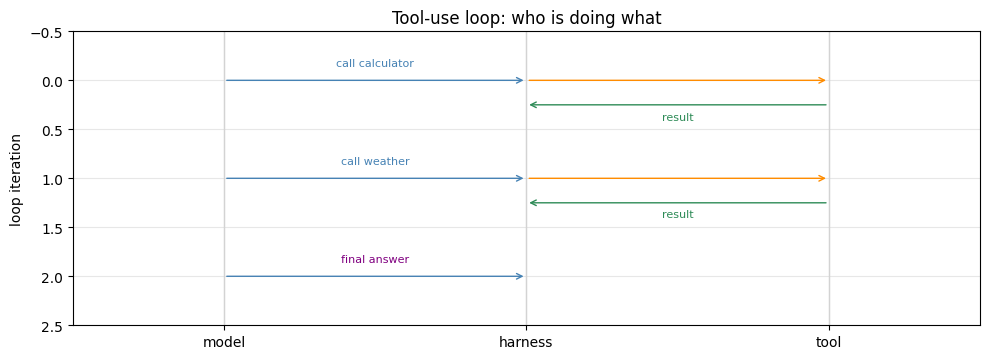

In [9]:
def plot_flow(trace):
    fig, ax = plt.subplots(figsize=(10, 0.9 * len(trace) + 1))
    cols = {'model': 0, 'harness': 1, 'tool': 2}
    for x, label in cols.items():
        ax.axvline(label, color='lightgray', linewidth=1)
    ax.set_xticks(list(cols.values()))
    ax.set_xticklabels(list(cols))
    ax.set_xlim(-0.5, 2.5)
    ax.set_ylim(-0.5, len(trace) - 0.5)
    ax.invert_yaxis()
    ax.set_ylabel('loop iteration')
    ax.set_title('Tool-use loop: who is doing what')

    for i, t in enumerate(trace):
        p = t['parsed']
        # model -> harness
        ax.annotate('', xy=(1, i), xytext=(0, i),
                    arrowprops=dict(arrowstyle='->', color='steelblue'))
        if p.kind == 'tool' and p.tool:
            ax.text(0.5, i - 0.15, f'call {p.tool}', ha='center', fontsize=8, color='steelblue')
            ax.annotate('', xy=(2, i), xytext=(1, i),
                        arrowprops=dict(arrowstyle='->', color='darkorange'))
            ax.annotate('', xy=(1, i + 0.25), xytext=(2, i + 0.25),
                        arrowprops=dict(arrowstyle='->', color='seagreen'))
            ax.text(1.5, i + 0.4, 'result', ha='center', fontsize=8, color='seagreen')
        elif p.kind == 'final':
            ax.text(0.5, i - 0.15, 'final answer', ha='center', fontsize=8, color='purple')
        else:
            ax.text(0.5, i - 0.15, 'malformed', ha='center', fontsize=8, color='red')
    plt.tight_layout(); plt.show()

plot_flow(trace)


## 9. Tool-call frequency: what does the model "decide"?

The first factor in our equation, $P(\text{tool}_i \mid \text{ctx})$, is a
classification over the tool vocabulary. We can simulate it: run a bunch of
queries through different scripted models and tally which tool gets picked.


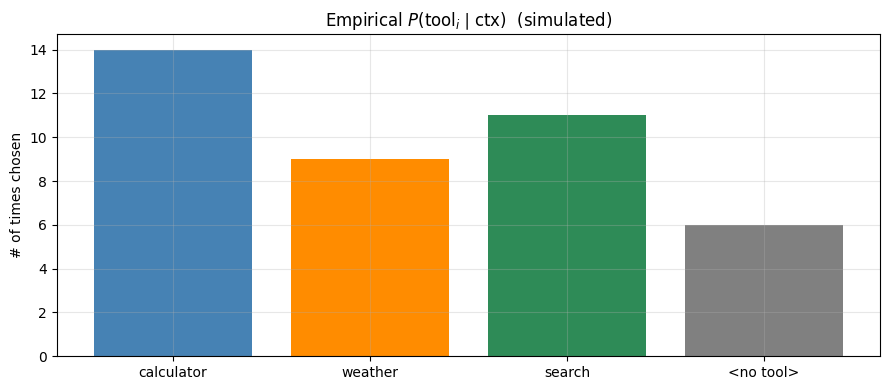

{'calculator': 14, 'weather': 9, 'search': 11, '<no tool>': 6}

In [10]:
# Simulate different query types: each script picks a different first tool.
queries = {
    'math':    ['<tool_call>{"tool":"calculator","args":{"expr":"7*8"}}</tool_call>',
                '<final>56</final>'],
    'weather': ['<tool_call>{"tool":"weather","args":{"city":"Tokyo"}}</tool_call>',
                '<final>24C clear</final>'],
    'fact':    ['<tool_call>{"tool":"search","args":{"query":"Eiffel"}}</tool_call>',
                '<final>330m tall</final>'],
    'chat':    ['<final>hello there</final>'],
}

# Pretend the model gets called many times with mixed prompts.
N_each = {'math': 14, 'weather': 9, 'fact': 11, 'chat': 6}
counts = {name: 0 for name in REGISTRY}
counts['<no tool>'] = 0

for kind, n in N_each.items():
    for _ in range(n):
        m = MockModel(queries[kind])
        _, tr = run_agent(m, f'simulated {kind} query', verbose=False)
        for t in tr:
            if t['parsed'].kind == 'tool' and t['parsed'].tool:
                counts[t['parsed'].tool] += 1
            elif t['parsed'].kind == 'final':
                # only count "no tool" if the very first step was final
                if t['step'] == 0:
                    counts['<no tool>'] += 1

fig, ax = plt.subplots()
names = list(counts)
ax.bar(names, [counts[n] for n in names], color=['steelblue','darkorange','seagreen','gray'])
ax.set_ylabel('# of times chosen')
ax.set_title('Empirical $P(\\mathrm{tool}_i \\mid \\mathrm{ctx})$  (simulated)')
plt.tight_layout(); plt.show()
counts


In a real system this distribution is very informative: it tells you
which tools you actually need, which are dead weight in the prompt, and
whether the model is over- or under-eager to call something. (Anthropic and
OpenAI both expose tool-choice analytics for exactly this reason.)

---

## 10. Break it on purpose

Time to abuse the harness. Each subsection is a real production failure
mode and the standard fix.

### Break #1 — invalid JSON


In [11]:
bad_json = MockModel([
    # missing closing brace
    '<tool_call>{"tool": "calculator", "args": {"expr": "2+2"</tool_call>',
    # second attempt: model corrects itself
    '<tool_call>{"tool": "calculator", "args": {"expr": "2+2"}}</tool_call>',
    '<final>4</final>',
])

answer, trace = run_agent(bad_json, 'compute 2+2', verbose=True)
print('\nfinal:', answer)



--- step 0: model said ---
<tool_call>{"tool": "calculator", "args": {"expr": "2+2"</tool_call>

--- step 1: model said ---
<tool_call>{"tool": "calculator", "args": {"expr": "2+2"}}</tool_call>
--- step 1: tool result ---
{'result': 4}

--- step 2: model said ---
<final>4</final>

final: 4


**Fix:** the harness catches `json.JSONDecodeError`, sends a `Format
error: ...` message back as a user turn, and the model retries. Real systems
also do **constrained decoding** (Outlines, JSON-Schema-guided sampling, vLLM's
`guided_json`) which prevents bad JSON from being generated in the first
place — token-level masking against the schema's grammar.

### Break #2 — non-existent tool


In [12]:
no_such_tool = MockModel([
    '<tool_call>{"tool": "summon_unicorn", "args": {"color": "pink"}}</tool_call>',
    # after seeing the error, fall back to a real tool
    '<tool_call>{"tool": "search", "args": {"query": "Eiffel"}}</tool_call>',
    '<final>Found it: 330m.</final>',
])

answer, trace = run_agent(no_such_tool, 'tell me about the Eiffel Tower')
print('\nfinal:', answer)



--- step 0: model said ---
<tool_call>{"tool": "summon_unicorn", "args": {"color": "pink"}}</tool_call>
--- step 0: tool result ---
{'error': "unknown tool 'summon_unicorn'. Available: ['calculator', 'weather', 'search']"}

--- step 1: model said ---
<tool_call>{"tool": "search", "args": {"query": "Eiffel"}}</tool_call>
--- step 1: tool result ---
{'result': ['The Eiffel Tower is 330 meters tall including antennas.']}

--- step 2: model said ---
<final>Found it: 330m.</final>

final: Found it: 330m.


**Fix:** registry lookup returns an `error` dict listing the actual
available tools. The model uses that hint to recover. The general pattern is
*errors are just more context* — never raise out of the loop, always serialize
the error and feed it back.

### Break #3 — infinite loop


In [13]:
# A model that compulsively calls the calculator forever.
loop_script = ['<tool_call>{"tool":"calculator","args":{"expr":"1+1"}}</tool_call>'] * 50

stuck = MockModel(loop_script)
answer, trace = run_agent(stuck, 'help', max_iters=5, verbose=False)
print('answer:', answer)
print('iterations consumed:', len(trace))


answer: None
iterations consumed: 5


**Fix:** `max_iters`. Always. Production harnesses additionally track
*repetition*: if the same `(tool, args)` shows up three times in a row, force
a `<final>` or escalate to a human. Some frameworks (LangGraph, OpenAI Agents
SDK) make this a first-class state-machine constraint.

### Break #4 — tool returns an error


In [14]:
tool_err = MockModel([
    # ask weather for a city we don't have
    '<tool_call>{"tool": "weather", "args": {"city": "Atlantis"}}</tool_call>',
    # error comes back; model picks a different city
    '<tool_call>{"tool": "weather", "args": {"city": "Paris"}}</tool_call>',
    '<final>Atlantis isn\'t in the database, but Paris is 19C partly cloudy.</final>',
])

answer, trace = run_agent(tool_err, 'is it warm in Atlantis?')
print('\nfinal:', answer)



--- step 0: model said ---
<tool_call>{"tool": "weather", "args": {"city": "Atlantis"}}</tool_call>
--- step 0: tool result ---
{'error': 'KeyError: "no weather data for \'Atlantis\'"'}

--- step 1: model said ---
<tool_call>{"tool": "weather", "args": {"city": "Paris"}}</tool_call>
--- step 1: tool result ---
{'result': {'temp_c': 19, 'condition': 'partly cloudy'}}

--- step 2: model said ---
<final>Atlantis isn't in the database, but Paris is 19C partly cloudy.</final>

final: Atlantis isn't in the database, but Paris is 19C partly cloudy.


**Fix:** the harness wraps `tool.call(...)` in `try/except` and serializes
the exception into the message stream as `{'error': '...'}`. The model reads
the error like any other observation and chooses what to do. *This is the
single highest-ROI line of code in any agent harness.*

### Break #5 — illegal arguments


In [15]:
illegal = MockModel([
    '<tool_call>{"tool": "calculator", "args": {"expr": "__import__(\'os\').system(\'ls\')"}}</tool_call>',
    '<final>That was blocked.</final>',
])

answer, trace = run_agent(illegal, 'try to escape')
print('\nfinal:', answer)



--- step 0: model said ---
<tool_call>{"tool": "calculator", "args": {"expr": "__import__('os').system('ls')"}}</tool_call>
--- step 0: tool result ---
{'error': 'ValueError: illegal characters in expr: "__import__(\'os\').system(\'ls\')"'}

--- step 1: model said ---
<final>That was blocked.</final>

final: That was blocked.


**Fix:** the calculator validates allowed characters before `eval`. In
production: never `eval`. Use `ast.literal_eval`, a real expression parser,
or a sandboxed subprocess. Tools are an attack surface; treat every argument
the model emits as adversarial input.

### Break #6 — missing required arg


In [16]:
missing_arg = MockModel([
    '<tool_call>{"tool": "calculator", "args": {}}</tool_call>',
    '<tool_call>{"tool": "calculator", "args": {"expr": "9*9"}}</tool_call>',
    '<final>81</final>',
])

answer, trace = run_agent(missing_arg, 'square nine')
print('\nfinal:', answer)



--- step 0: model said ---
<tool_call>{"tool": "calculator", "args": {}}</tool_call>
--- step 0: tool result ---
{'error': "TypeError: calculator() missing 1 required positional argument: 'expr'"}

--- step 1: model said ---
<tool_call>{"tool": "calculator", "args": {"expr": "9*9"}}</tool_call>
--- step 1: tool result ---
{'result': 81}

--- step 2: model said ---
<final>81</final>

final: 81


Python raises `TypeError: calculator() missing 1 required positional
argument: 'expr'`. Our `try/except` catches it and feeds it back. The model
sees `TypeError` and adds the missing field on the next turn.

A more polished harness would validate against the JSON schema *before*
calling the function and produce a friendlier message — but the recovery
behavior is the same.

### Break #7 — model never calls a tool when it should


In [17]:
hallucinator = MockModel([
    '<final>15% of 240 is approximately 35.</final>',  # wrong! model guessed
])

answer, trace = run_agent(hallucinator, 'what is 15% of 240?')
print('answer:', answer, '   (correct value: 36.0)')



--- step 0: model said ---
<final>15% of 240 is approximately 35.</final>
answer: 15% of 240 is approximately 35.    (correct value: 36.0)


**Fix:** this is a *training* problem, not a harness problem. The
production lever is the system prompt: explicit instructions like *"For any
arithmetic, you MUST use the calculator tool. Do not estimate."* Combined
with a few-shot example, this works well in practice. RL-tuned tool models
(Anthropic, OpenAI) bake this preference in during training so the prompt
doesn't have to.

### Break #8 — model emits two tool calls at once


In [18]:
parallel = MockModel([
    '<tool_call>{"tool":"calculator","args":{"expr":"2+2"}}</tool_call>'
    '<tool_call>{"tool":"weather","args":{"city":"Paris"}}</tool_call>',
    '<final>4 and 19C</final>',
])

# our parser only grabs the FIRST tool_call. The second is silently dropped.
answer, trace = run_agent(parallel, 'two things at once')
print('answer:', answer)
print('parsed first call:', trace[0]['parsed'])



--- step 0: model said ---
<tool_call>{"tool":"calculator","args":{"expr":"2+2"}}</tool_call><tool_call>{"tool":"weather","args":{"city":"Paris"}}</tool_call>
--- step 0: tool result ---
{'result': 4}

--- step 1: model said ---
<final>4 and 19C</final>
answer: 4 and 19C
parsed first call: ParsedCall(kind='tool', tool='calculator', args={'expr': '2+2'}, text=None, error=None)


**Fix:** real APIs (OpenAI's `tool_calls` array, Anthropic's parallel
tool use) explicitly support **parallel** tool calls. The harness change is
small: `findall` instead of `search`, dispatch all of them, then inject *all*
the results in a single tool message. We're skipping it here for clarity, but
it is one extra `for` loop.

### Break #9 — context blows up


In [19]:
# Pretend each tool result is a 5KB blob; what happens to the prompt size?
big_script = ['<tool_call>{"tool":"search","args":{"query":"Paris"}}</tool_call>'] * 10 + ['<final>done</final>']
big_model = MockModel(big_script)

# instrument the registry temporarily
orig = REGISTRY['search'].fn
REGISTRY['search'].fn = lambda query: ['x' * 5000]
try:
    _, tr = run_agent(big_model, 'spam search', max_iters=11, verbose=False)
finally:
    REGISTRY['search'].fn = orig

# count chars in the conversation
total = 0
for t in tr:
    total += len(t['raw'])
print(f'tool-result chars accumulated: ~{10 * 5000}')
print(f'model output chars (no growth here because mock):', total)


tool-result chars accumulated: ~50000
model output chars (no growth here because mock): 669


**Fix:** every long-running agent eventually hits the context limit.
Production harnesses **summarize** old tool results, **truncate** large blobs,
or **swap out** the conversation into vector storage and re-retrieve the
relevant pieces. Module 31 will show one strategy; the *Agents & Eval* part
of the curriculum revisits it in detail.

### Break #10 — harness assumes the model speaks the format

What if you point the harness at a base model that has *not* been fine-tuned
for tool use? It will produce free-form prose with no `<tool_call>` tags at
all, the parser falls into the `'none'` branch forever, and `max_iters`
saves you.


In [20]:
raw_base_model = MockModel(['Sure, 15% of 240 is 36 and Paris is usually mild.'] * 5)
answer, trace = run_agent(raw_base_model, 'compute and check weather', max_iters=3, verbose=False)
print('answer:', answer)
print('format errors per step:', [t['parsed'].error for t in trace])


answer: None
format errors per step: ['no tool_call or final tag found', 'no tool_call or final tag found', 'no tool_call or final tag found']


**Fix:** use a model that has been instruction-tuned for tools. This is
why every provider sells a "tool-use-tuned" variant. Or, on a base model,
use **constrained decoding** to *force* the format — at the cost of some
flexibility. The point of this break is to remind you the format is a
learned behavior, not a property of language models.

---

## 11. The same trick under three brand names

Quick map between what we built and what the providers ship:

| | **Ours** | **OpenAI** | **Anthropic** | **Llama 3.1** |
|---|---|---|---|---|
| Tool list | `REGISTRY` dict | `tools=[...]` param | `tools=[...]` param | `tools` in system prompt |
| Tool call format | `<tool_call>{...}</tool_call>` | `tool_calls[]` JSON | `tool_use` content block | `<\|python_tag\|>{...}` |
| Result injection | `{'role':'tool', ...}` | `{'role':'tool', ...}` | `tool_result` block | `<\|tool_response\|>` |
| Parsing | regex + json.loads | done by SDK | done by SDK | regex + json.loads |
| Constrained decoding | none | `tool_choice='required'` | `tool_choice` field | grammar-guided sampling |

Different tags, identical loop. If you understand the 30-line harness above
you understand all three. The fancy SDKs add: streaming, parallel calls,
schema validation, retries, observability — none of which change the core.

## 12. (Optional) plug in a real tiny model

If you have `transformers` installed and want to see a *real* LLM emit a
tool call, swap `MockModel` for the wrapper below. Any small instruction-tuned
model works (e.g., `Qwen2.5-0.5B-Instruct`, `Llama-3.2-1B-Instruct`,
`SmolLM2-360M-Instruct`). It will be wobbly — small models are not great at
strict JSON — and that is *the* lesson: tool reliability is a function of
model size and post-training, not of harness cleverness.


In [21]:
# uncomment to try with a real model:
#
# from transformers import AutoTokenizer, AutoModelForCausalLM
# import torch
#
# class HFModel:
#     def __init__(self, model_id='Qwen/Qwen2.5-0.5B-Instruct'):
#         self.tok = AutoTokenizer.from_pretrained(model_id)
#         self.lm  = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.float32)
#         self.lm.eval()
#
#     def __call__(self, messages):
#         # most chat models accept the same role-list our harness uses
#         text = self.tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
#         ids  = self.tok(text, return_tensors='pt').input_ids
#         with torch.no_grad():
#             out = self.lm.generate(ids, max_new_tokens=200, do_sample=False)
#         return self.tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True)
#
# real = HFModel()
# answer, trace = run_agent(real, 'What is 15% of 240, and is it warm in Paris?')
# print(answer)
print('(commented out — uncomment if transformers is installed)')


(commented out — uncomment if transformers is installed)


## 13. What you should walk away with

1. **Tool calling = constrained text generation + a parser.** No magic.
2. The harness is ~80 lines and does ~90% of the work. The model just emits
   structured text.
3. The five primitives are: registry, model, parser, dispatcher, loop.
4. Failure modes are 90% harness bugs (bad parsing, infinite loops, no
   error injection) and only 10% model bugs.
5. OpenAI / Anthropic / Llama all use the same trick with different tags.
6. Constrained decoding (JSON schema enforcement at the token level) is the
   "industrial strength" version of our regex parser.

## 14. Bridge to Module 31

What we just built is technically already an "agent" — an LLM in a loop with
tools. Module 31 will name the parts (state, memory, dispatch, ReAct), turn
the loop into an explicit state machine, and show that **most agent
failures are harness failures**, not model failures. We are going to debug a
broken harness step-by-step until it works.

> See you in Module 31.


---

### Checkpoint quiz

1. Why does it make sense to say *the model doesn't know it called a tool*?
2. What is the difference between *constrained decoding* and *parsing after
   the fact*? Which one prevents bad JSON, and which one recovers from it?
3. In our harness, what happens if you delete the `try/except` around
   `tool.call(...)`? Trace through Break #4 mentally.
4. The factorization
   $P(\text{tool}_i, \text{args} \mid \text{ctx}) = P(\text{tool}_i \mid \text{ctx}) \cdot P(\text{args} \mid \text{tool}_i, \text{ctx})$
   suggests two different ways the model can fail. Name them.
5. You inspect production logs and see the same tool being called four times
   in a row with identical arguments. Which break in this notebook predicted
   that, and what is the fix?
